**Name : Ashwini Khushal Barapatre**

**USN No. : CS23118**

**Lab 4 Extra Datasets**

**Aim: To implement a Decision Tree regression model on the Developer Performance dataset and analyze how different tree depths and splitting criteria influence model performance.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path= "/content/drive/MyDrive/ML Dataset/Developer_Performance_dataset_1000 - Developer_Performance_dataset_1000.csv"
df=pd.read_csv(path)
df.head(5)

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
0,7,416,9,7,6,5.9,92,7,99,10.5,20,3,34
1,4,269,16,13,5,5.1,85,2,100,9.5,17,8,36
2,11,439,3,0,2,6.2,38,2,55,18.3,35,2,79
3,8,472,15,9,4,4.2,26,5,30,12.6,28,4,94
4,5,265,19,16,5,8.1,82,6,82,7.0,25,9,33


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hours_Coding         1000 non-null   int64  
 1   Lines_of_Code        1000 non-null   int64  
 2   Bugs_Found           1000 non-null   int64  
 3   Bugs_Fixed           1000 non-null   int64  
 4   AI_Usage_Hours       1000 non-null   int64  
 5   Sleep_Hours          1000 non-null   float64
 6   Cognitive_Load       1000 non-null   int64  
 7   Coffee_Intake        1000 non-null   int64  
 8   Stress_Level         1000 non-null   int64  
 9   Task_Duration_Hours  1000 non-null   float64
 10  Commits              1000 non-null   int64  
 11  Errors               1000 non-null   int64  
 12  Task_Success_Rate    1000 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 101.7 KB


In [5]:
df.shape

(1000, 13)

In [6]:
df.columns

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Errors',
       'Task_Success_Rate'],
      dtype='object')

In [7]:
df.isnull().any().any()

np.False_

In [8]:
df.isnull().sum()

,0
Hours_Coding,0
Lines_of_Code,0
Bugs_Found,0
Bugs_Fixed,0
AI_Usage_Hours,0
Sleep_Hours,0
Cognitive_Load,0
Coffee_Intake,0
Stress_Level,0
Task_Duration_Hours,0


In [9]:
df[df.isnull().any(axis=1)]

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate


In [10]:
X = df.drop("Task_Success_Rate", axis=1)
y = df["Task_Success_Rate"]

In [ ]:
df["Productivity"] = df["Lines_of_Code"] / df["Hours_Coding"]
df.head()

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate,Productivity
0,7,416,9,7,6,5.9,92,7,99,10.5,20,3,34,59.428571
1,4,269,16,13,5,5.1,85,2,100,9.5,17,8,36,67.250000
2,11,439,3,0,2,6.2,38,2,55,18.3,35,2,79,39.909091
3,8,472,15,9,4,4.2,26,5,30,12.6,28,4,94,59.000000
4,5,265,19,16,5,8.1,82,6,82,7.0,25,9,33,53.000000


In [ ]:
X = df.drop(columns=['Task_Success_Rate'])
y = df['Task_Success_Rate']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
df["Performance"] = df["Task_Success_Rate"].apply(lambda x: 1 if x >= 60 else 0)

In [12]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y, train_size=0.7, test_size=0.3, random_state=42)

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.9163235167858662
MSE: 33.58083333333333


In [30]:
depths = [2, 4, 6, 8, 10, 15]
r2_scores = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

print(r2_scores)

[0.8207170605084363, 0.8980815221945584, 0.9079872175775411, 0.8840433720725455, 0.874285124393865, 0.8772542800765845]


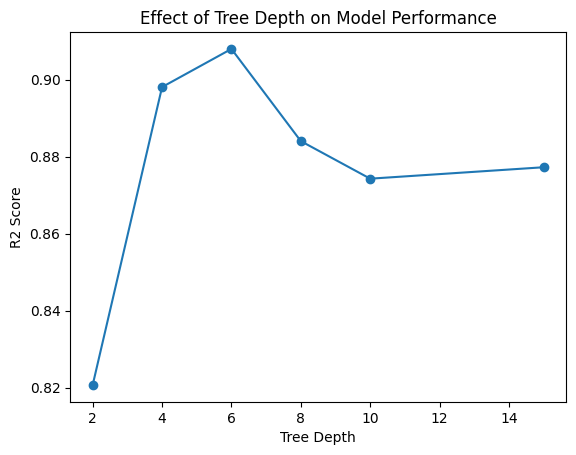

In [31]:
import matplotlib.pyplot as plt

plt.plot(depths, r2_scores, marker='o')
plt.xlabel("Tree Depth")
plt.ylabel("R2 Score")
plt.title("Effect of Tree Depth on Model Performance")
plt.show()

In [18]:
criteria = ["squared_error", "absolute_error"]

for crit in criteria:
    model = DecisionTreeRegressor(
        criterion=crit,
        max_depth=6,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\nCriterion:", crit)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))


Criterion: squared_error
R2 Score: 0.9185799214046445
MSE: 32.98342853712783

Criterion: absolute_error
R2 Score: 0.8995499650828594
MSE: 40.6925


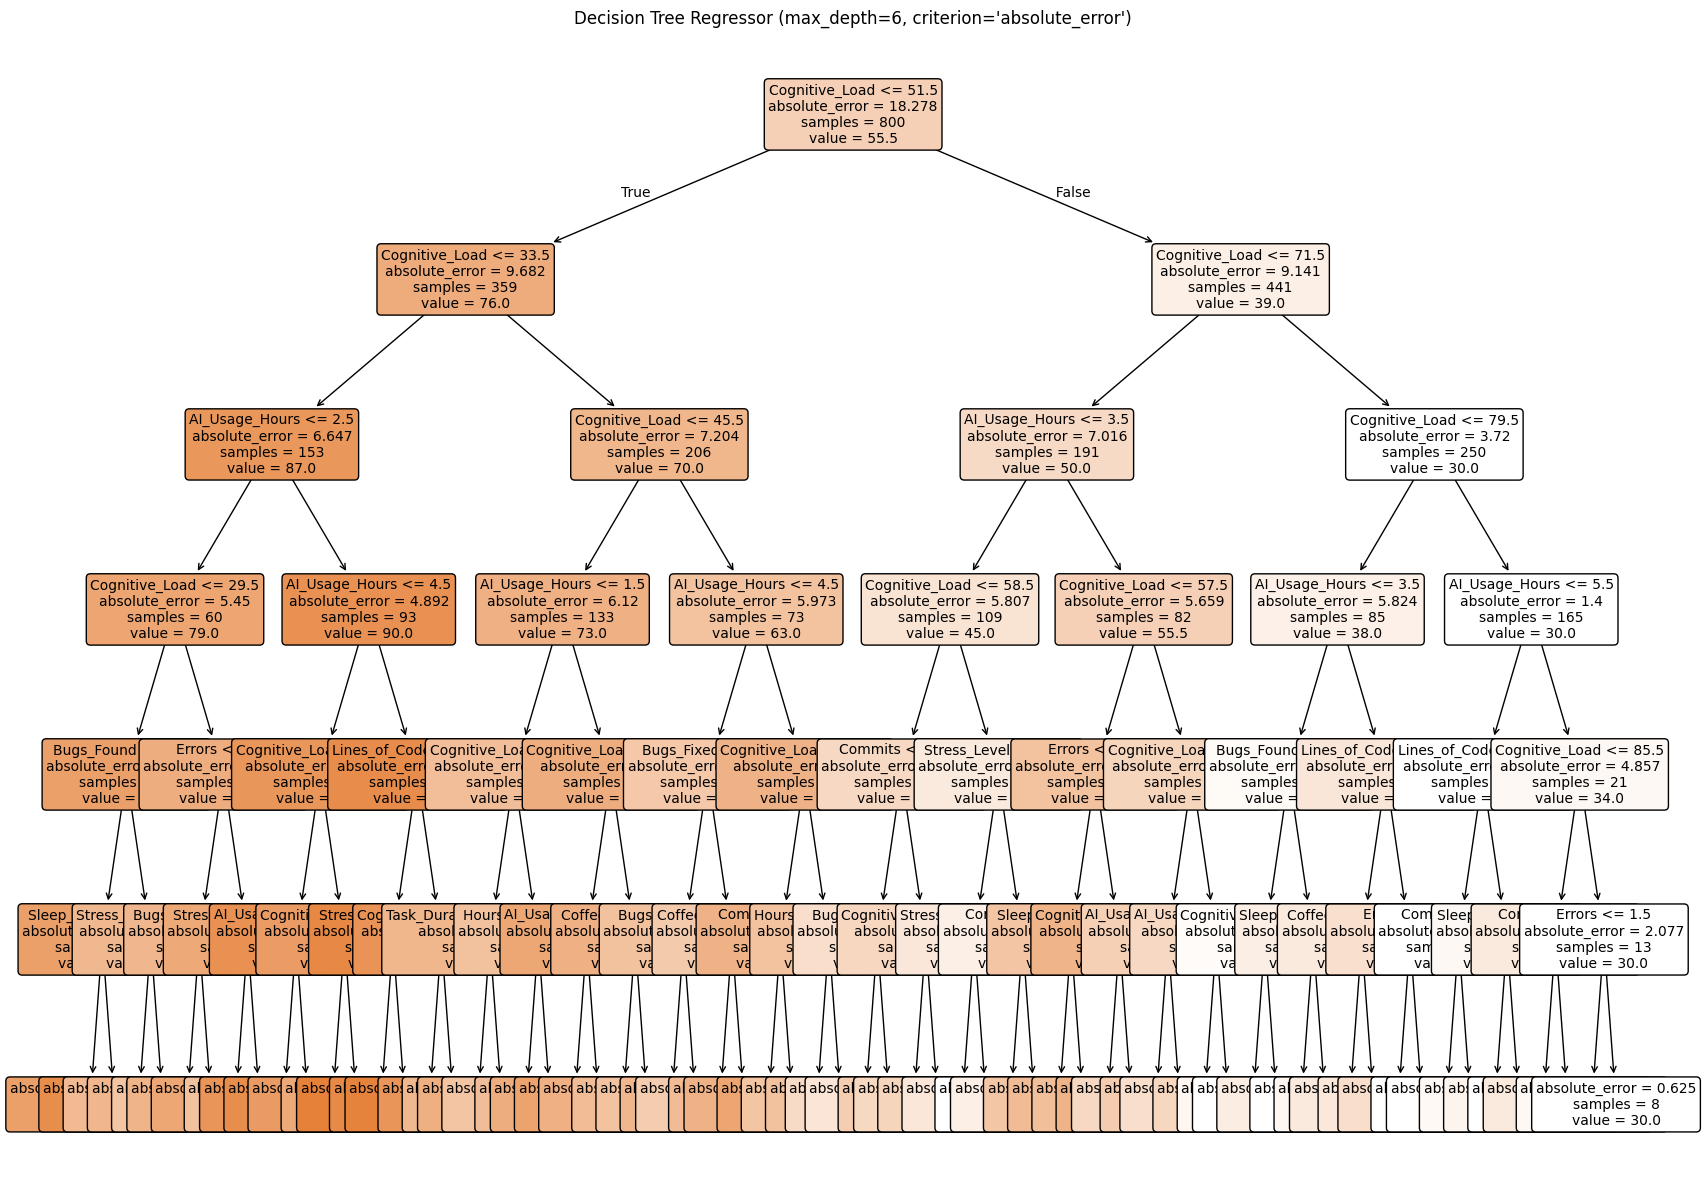

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,15)) # Increased figure size for better visibility
plot_tree(model, filled=True, feature_names=X_train.columns, rounded=True, fontsize=10)
plt.title("Decision Tree Regressor (max_depth=6, criterion='absolute_error')")
plt.show()

In [35]:
y_pred = model.predict(X_test)
print(y_pred)

[ 36.  31.  39.  42.  69.  30.  56.  67.  61.  36.  51.  50.  63.  78.
  50.  30.  61.  72.  85.  90.  58.  42.  56.  56.  64.  42.  90.  38.
  60.  33.  30.  81.  42.  92.  78.  54.  62.  87.  45.  58.  30.  87.
  90.  54.  82.  72.  30.  42.  48.  83.  39.  52.  78.  65.  41.  56.
  60.  66.  30.  43.  36.  71.  53.  69.  30.  90.  30.  62.  30.  56.
  82.  73.  30.  44.  30.  90.  46.  38.  30.  46.  46.  87.  43.  56.
  87.  41.  52.  75.  39.  58.  80.  72.  30.  30.  75.  48.  30.  30.
  52.  66.  81.  63.  64.  43.  37.  62.  98.  82.  45.  30.  49.  52.
  72.  54.  90.  37.  30.  71.  56.  30.  34.  30.  39.  50.  30.  75.
  30.  63.  69.  32.  35.  79.  84.  80.  67.  39.  30.  87.  85.  50.
  85.  85.  79.  30.  31.  60.  30.  33.  83.  52.  84.  30.  39.  51.
  80.  48.  46.  73.  44.  75.  57.  48.  63.  41.  33.  72.  30.  40.
  69.  98.  67.  31.  30.  49.  50.  85.  44.  30.  81.  37.  86.  73.
  41.  31.  76.  93.  44.  70.  81.  56.  30.  43.  30.  33.  78.  65.
  35. 

In [40]:
print(confusion_matrix(y_test, y_pred))

[[40  3  4 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 1  0  0 ...  0  0  0]
 ...
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  1]]


In [36]:
from sklearn.metrics import confusion_matrix

# Binarize y_test and y_pred using a threshold of 60
y_test_classified = (y_test >= 60).astype(int)
y_pred_classified = (y_pred >= 60).astype(int)

# Now, calculate and print the confusion matrix
print("Confusion Matrix (Task_Success_Rate >= 60 as 1, else 0):")
print(confusion_matrix(y_test_classified, y_pred_classified))

Confusion Matrix (Task_Success_Rate >= 60 as 1, else 0):
[[164  13]
 [ 13 110]]


In [37]:
accuracy= accuracy_score(y_test,y_pred)
print(accuracy)

0.17666666666666667


In [38]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        30.0       0.78      0.70      0.74        57
        31.0       0.00      0.00      0.00         2
        32.0       0.00      0.00      0.00         4
        33.0       0.00      0.00      0.00         3
        34.0       0.00      0.00      0.00         2
        35.0       0.00      0.00      0.00         3
        36.0       0.00      0.00      0.00         5
        37.0       0.00      0.00      0.00         4
        38.0       0.00      0.00      0.00         6
        39.0       0.10      0.20      0.13         5
        40.0       0.33      0.17      0.22         6
        41.0       0.20      0.25      0.22         4
        42.0       0.00      0.00      0.00         8
        43.0       0.00      0.00      0.00         4
        44.0       0.00      0.00      0.00         4
        45.0       0.25      0.50      0.33         2
        46.0       0.00      0.00      0.00         5
        47.0       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_